# Matter, NSI, and Lorentz-invariance violation

Constant-density matter, and two kinds of new physics. Each is a different Hamiltonian passed to the same routine — which is the point the library is built around.

In [1]:
import sys
import os

# Works whether or not the package is installed: the notebooks sit one level
# below the repository root, as the worked examples in test/ do.
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import matplotlib.pyplot as plt

import globaldefs as gd
import oscprob2nu
import oscprob3nu
import hamiltonians2nu
import hamiltonians3nu

%matplotlib inline
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 90,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'legend.frameon': False})

# The three-flavor vacuum Hamiltonian at the NuFit best fit, normal ordering.
# It is energy-independent; dividing by the energy is what the builders do.
H_VAC_3NU = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, gd.DCP_NO_BF,
    gd.D21_NO_BF, gd.D31_NO_BF)

KM = gd.CONV_KM_TO_INV_EV      # multiply a length in km to get eV^-1
GEV = 1.0e9                    # multiply an energy in GeV to get eV

## Matter of constant density

Adding the charged-current potential $V_{CC}$ to the $ee$ entry produces the MSW resonance: a peak in $P_{e\mu}$ at the energy where the matter term cancels the vacuum one.

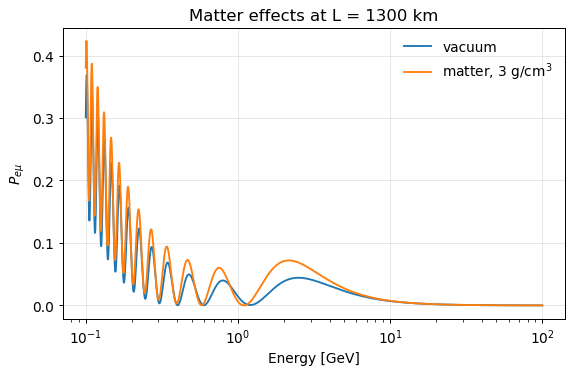

In [2]:
E_gev = np.logspace(-1.0, 2.0, 2000)
L = 1300.0*KM

H_vac = np.asarray(H_VAC_3NU)/(E_gev[:, None, None]*GEV)
H_mat = hamiltonians3nu.hamiltonian_3nu_matter(
    H_VAC_3NU, E_gev*GEV, gd.VCC_EARTH_CRUST)

p_vac = oscprob3nu.probabilities_3nu(H_vac, L)
p_mat = oscprob3nu.probabilities_3nu(H_mat, L)

fig, ax = plt.subplots()
ax.semilogx(E_gev, p_vac[:, 1], label="vacuum")
ax.semilogx(E_gev, p_mat[:, 1], label="matter, 3 g/cm$^3$")
ax.set_xlabel("Energy [GeV]")
ax.set_ylabel(r"$P_{e\mu}$")
ax.set_title("Matter effects at L = 1300 km")
ax.legend()
plt.show()

The builders take an **array** of energies and return one Hamiltonian per energy, stacked. That is why the matter curve above needed no loop.

## Non-standard interactions

NSI add an effective potential with its own flavor structure, parametrised by the $\epsilon$ matrix.

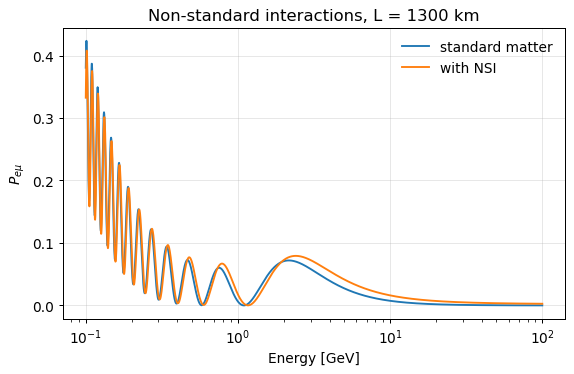

In [3]:
H_nsi = hamiltonians3nu.hamiltonian_3nu_nsi(
    H_VAC_3NU, E_gev*GEV, gd.VCC_EARTH_CRUST, gd.EPS_3)
p_nsi = oscprob3nu.probabilities_3nu(H_nsi, L)

fig, ax = plt.subplots()
ax.semilogx(E_gev, p_mat[:, 1], label="standard matter")
ax.semilogx(E_gev, p_nsi[:, 1], label="with NSI")
ax.set_xlabel("Energy [GeV]")
ax.set_ylabel(r"$P_{e\mu}$")
ax.set_title("Non-standard interactions, L = 1300 km")
ax.legend()
plt.show()

## Lorentz-invariance violation

A CPT-odd LIV background contributes a term that grows with energy rather than falling, so it shows up at the high end.

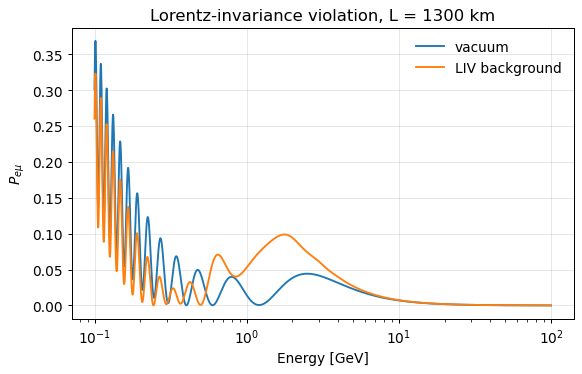

In [4]:
H_liv = hamiltonians3nu.hamiltonian_3nu_liv(
    H_VAC_3NU, E_gev*GEV, gd.SXI12, gd.SXI23, gd.SXI13,
    gd.DXICP, gd.B1, gd.B2, gd.B3, gd.LAMBDA)
p_liv = oscprob3nu.probabilities_3nu(H_liv, L)

fig, ax = plt.subplots()
ax.semilogx(E_gev, p_vac[:, 1], label="vacuum")
ax.semilogx(E_gev, p_liv[:, 1], label="LIV background")
ax.set_xlabel("Energy [GeV]")
ax.set_ylabel(r"$P_{e\mu}$")
ax.set_title("Lorentz-invariance violation, L = 1300 km")
ax.legend()
plt.show()